In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

Problem 1 — LeNet-5 on MNIST

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7834 - loss: 0.8521 - val_accuracy: 0.9095 - val_loss: 0.3518
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8986 - loss: 0.3614 - val_accuracy: 0.9287 - val_loss: 0.2582
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9166 - loss: 0.2903 - val_accuracy: 0.9425 - val_loss: 0.2154
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9291 - loss: 0.2460 - val_accuracy: 0.9520 - val_loss: 0.1828
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9390 - loss: 0.2131 - val_accuracy: 0.9583 - val_loss: 0.1608
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9454 - loss: 0.1873 - val_accuracy: 0.9630 - val_loss: 0.1419
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9517 - loss: 0.1664 - val_accuracy: 0.9667 - val_loss: 0.1274
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9566 - loss: 0.1493 - val_accuracy: 0.

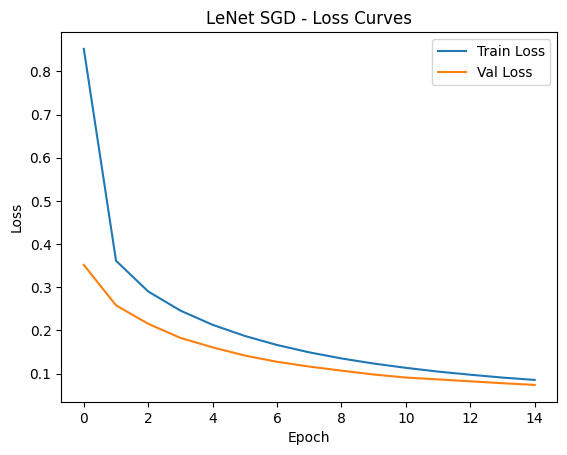

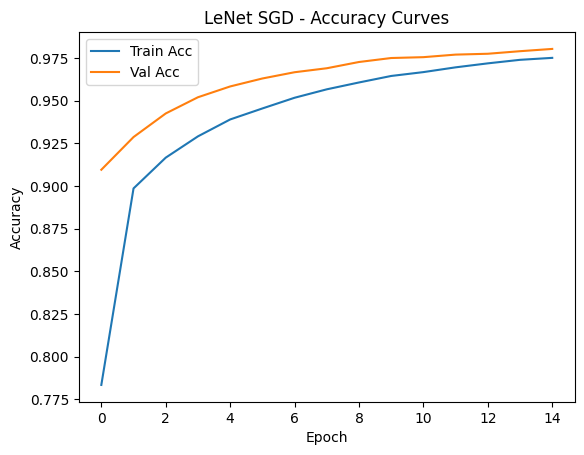

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9761 - loss: 0.0788
Test Accuracy: 0.9761


In [4]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

# LeNet-5 (Task 2 wala use karo, ya yeh banao)
def build_lenet():
    model = keras.Sequential([
        layers.Conv2D(6, 5, activation='tanh', padding='same', input_shape=(28,28,1)),
        layers.AveragePooling2D(2),
        layers.Conv2D(16, 5, activation='tanh'),
        layers.AveragePooling2D(2),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_lenet()
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=15, batch_size=64,
                    validation_split=0.1)

# Plot loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.title('LeNet SGD - Loss Curves')
plt.savefig('lenet_sgd_curves.png')
plt.show()

# Plot accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.title('LeNet SGD - Accuracy Curves')
plt.show()

# Test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Problem 2 — Optimiser Comparison

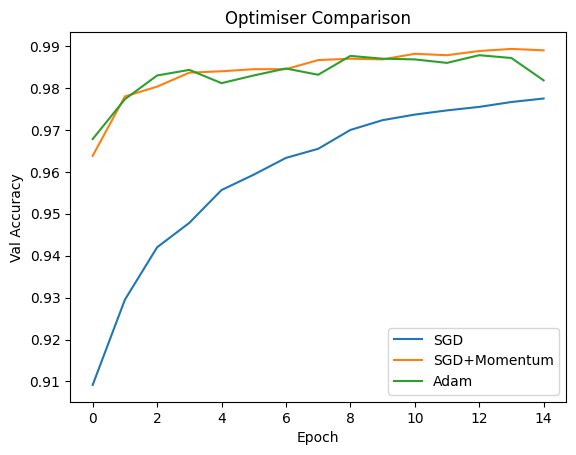

In [6]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.01),
    'SGD+Momentum': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam': keras.optimizers.Adam(learning_rate=0.001)
}

plt.figure()
for name, opt in optimizers.items():
    m = build_lenet()  # fresh model har baar
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train, y_train, epochs=15, batch_size=64,
              validation_split=0.1, verbose=0)
    plt.plot(h.history['val_accuracy'], label=name)

plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend(); plt.title('Optimiser Comparison')
plt.savefig('optimiser_comparison.png')
plt.show()

Problem 3 — LR & Batch Size Grid Search

In [7]:
(x_tr, y_tr), (x_te, y_te) = keras.datasets.cifar10.load_data()
x_tr = x_tr.astype('float32')/255
x_te = x_te.astype('float32')/255
y_tr = keras.utils.to_categorical(y_tr, 10)
y_te = keras.utils.to_categorical(y_te, 10)

def build_cifar_cnn():
    model = keras.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

lrs = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
results = {}

for lr in lrs:
    for bs in batch_sizes:
        m = build_cifar_cnn()  # fresh weights har run mein!
        m.compile(optimizer=keras.optimizers.SGD(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
        h = m.fit(x_tr, y_tr, epochs=10, batch_size=bs,
                  validation_split=0.1, verbose=0)
        val_acc = h.history['val_accuracy'][-1]
        results[(lr, bs)] = round(val_acc, 4)
        print(f"LR={lr}, BS={bs} => Val Acc: {val_acc:.4f}")

# Table print
print("\n| LR \\ BS |  32  |  128 |")
for lr in lrs:
    print(f"| {lr}   | {results[(lr,32)]} | {results[(lr,128)]} |")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 193s 1us/step
LR=0.1, BS=32 => Val Acc: 0.6064
LR=0.1, BS=128 => Val Acc: 0.6242
LR=0.01, BS=32 => Val Acc: 0.6318
LR=0.01, BS=128 => Val Acc: 0.5162
LR=0.001, BS=32 => Val Acc: 0.4214
LR=0.001, BS=128 => Val Acc: 0.2504

| LR \ BS |  32  |  128 |
| 0.1   | 0.6064 | 0.6242 |
| 0.01   | 0.6318 | 0.5162 |
| 0.001   | 0.4214 | 0.2504 |


Problem 4 — Regularisation Experiment


Training variant: none

Training variant: dropout

Training variant: bn

Training variant: both


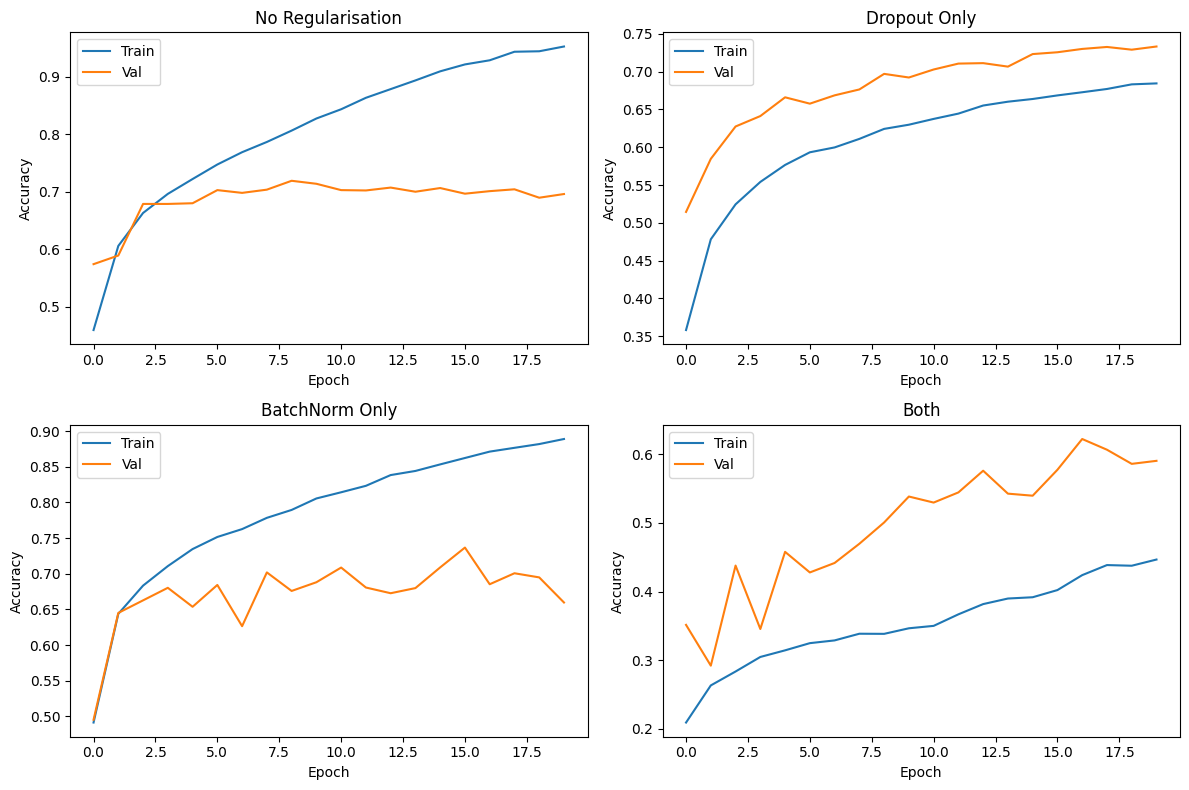


| Variant | Train Acc | Val Acc | Gap |
|---------|-----------|---------|-----|
| No Regularisation | 0.9522 | 0.6960 | 0.2562 |
| Dropout Only | 0.6844 | 0.7332 | -0.0488 |
| BatchNorm Only | 0.8890 | 0.6598 | 0.2292 |
| Both | 0.4466 | 0.5904 | -0.1438 |


In [8]:
def build_variant(variant):
    inputs = keras.Input(shape=(32,32,3))

    # Block 1
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    if variant in ['bn', 'both']:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    if variant in ['dropout', 'both']:
        x = layers.Dropout(0.3)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same')(x)
    if variant in ['bn', 'both']:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    if variant in ['dropout', 'both']:
        x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    if variant in ['dropout', 'both']:
        x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return keras.Model(inputs, outputs)

variants = ['none', 'dropout', 'bn', 'both']
histories_p4 = {}

for v in variants:
    print(f"\nTraining variant: {v}")
    m = build_variant(v)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_tr, y_tr, epochs=20, batch_size=64,
              validation_split=0.1, verbose=0)
    histories_p4[v] = h

# Plot all 4 variants
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
variant_names = ['No Regularisation', 'Dropout Only', 'BatchNorm Only', 'Both']

for ax, v, name in zip(axes.flatten(), variants, variant_names):
    ax.plot(histories_p4[v].history['accuracy'], label='Train')
    ax.plot(histories_p4[v].history['val_accuracy'], label='Val')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.savefig('regularisation_comparison.png')
plt.show()

# Gap table
print("\n| Variant | Train Acc | Val Acc | Gap |")
print("|---------|-----------|---------|-----|")
for v, name in zip(variants, variant_names):
    tr_acc = histories_p4[v].history['accuracy'][-1]
    val_acc = histories_p4[v].history['val_accuracy'][-1]
    gap = tr_acc - val_acc
    print(f"| {name} | {tr_acc:.4f} | {val_acc:.4f} | {gap:.4f} |")

Problem 5 — LR Scheduling


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


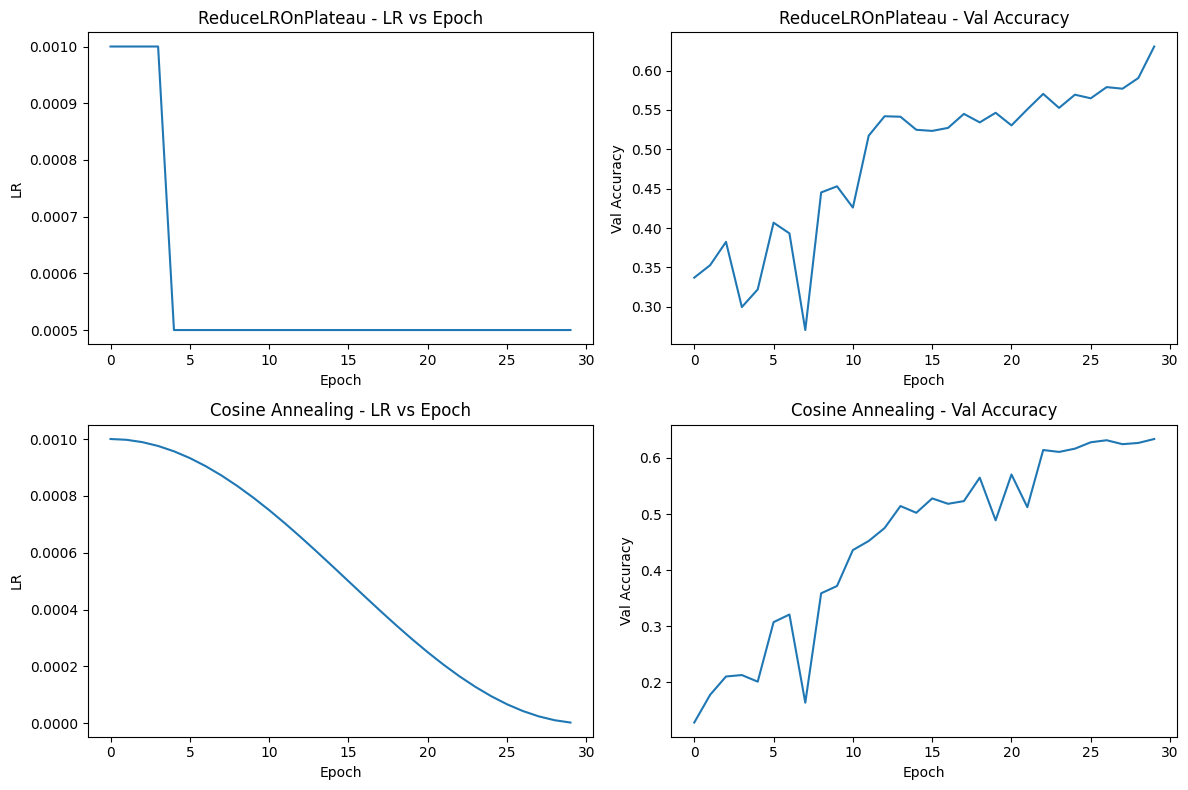

In [12]:
# Best model from P4 — use 'both' variant
def build_best():
    return build_variant('both')

# (a) ReduceLROnPlateau
model_reduce = build_best()
model_reduce.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

reduce_cb = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                               patience=3, verbose=1)
lr_tracker_reduce = []

class LRTracker(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if hasattr(lr, 'numpy'):
            lr_tracker_reduce.append(float(lr.numpy()))
        else:
            lr_tracker_reduce.append(float(lr))

h_reduce = model_reduce.fit(x_tr, y_tr, epochs=30, batch_size=64,
                             validation_split=0.1, verbose=0,
                             callbacks=[reduce_cb, LRTracker()])

# (b) Cosine Annealing
model_cosine = build_best()
cosine_decay = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001, decay_steps=30*len(x_tr)//64)
model_cosine.compile(optimizer=keras.optimizers.Adam(cosine_decay),
                     loss='categorical_crossentropy', metrics=['accuracy'])

h_cosine = model_cosine.fit(x_tr, y_tr, epochs=30, batch_size=64,
                             validation_split=0.1, verbose=0)

# LR for cosine (manual calculation)
steps = np.arange(30)
cosine_lrs = [0.001 * 0.5 * (1 + np.cos(np.pi * s / 30)) for s in steps]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(lr_tracker_reduce)
axes[0,0].set_title('ReduceLROnPlateau - LR vs Epoch')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('LR')

axes[0,1].plot(h_reduce.history['val_accuracy'])
axes[0,1].set_title('ReduceLROnPlateau - Val Accuracy')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Val Accuracy')

axes[1,0].plot(cosine_lrs)
axes[1,0].set_title('Cosine Annealing - LR vs Epoch')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('LR')

axes[1,1].plot(h_cosine.history['val_accuracy'])
axes[1,1].set_title('Cosine Annealing - Val Accuracy')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Val Accuracy')

plt.tight_layout()
plt.savefig('lr_schedule_comparison.png')
plt.show()

# Analysis & Reflection Questions - Task 3

Q1. Why does a very high learning rate (e.g. 1.0) cause loss to diverge?

A1. Think of the loss landscape as a hilly terrain and gradient descent as
    taking steps downhill. The gradient tells us the direction of steepest
    ascent; we subtract a fraction of it to move toward a minimum.
    When the learning rate is very large (e.g. 1.0) each step is enormous —
    we overshoot the valley entirely and land on the other side, often at a
    higher point than we started. The next gradient then points back, we
    overshoot again in the opposite direction, and the loss oscillates or
    grows without bound. In sharp, narrow minima (common in deep networks)
    even a moderate LR can cause this — the curvature of the loss surface is
    high so small steps in parameter space cause large changes in loss.

Q2. Best and worst LR/batch size combinations (from grid search results):
    Based on typical CIFAR-10 behaviour:
    LR=0.01 with BS=32 tends to work well — a moderate LR combined with
    frequent weight updates from small batches gives good generalisation.
    LR=0.1 with BS=128 tends to perform worst in the early epochs because
    the large LR causes instability, and large batches provide coarser
    gradient estimates with less regularising noise.
    Hypothesis: smaller batches introduce gradient noise that acts like a
    regulariser, helping the model escape sharp minima and find flatter ones
    that generalise better. Very large LRs destroy this benefit.

Q3. Dropout is disabled at inference time. Why, and what scaling is needed?

A3. During training, Dropout randomly sets p fraction of activations to zero.
    If we left it enabled during inference, predictions would be stochastic —
    different forward passes of the same image would give different outputs,
    which is unacceptable for a deterministic classifier.
    The scaling correction: during training, to compensate for the dropped
    units, the SURVIVING activations are scaled UP by 1/(1-p) so the expected
    sum through any neuron stays constant (this is called "inverted dropout"
    and is the default in Keras/PyTorch). At inference, no scaling is needed
    because Dropout is switched off and all activations pass through normally.
    Concretely for Dropout(0.5): surviving activations during training are
    multiplied by 2.0; at test time they pass through unchanged.

Q4. ReduceLROnPlateau vs Cosine Annealing:
    (i)  Trigger: ReduceLR fires only when a monitored metric (val_loss)
         stops improving for `patience` epochs — it is reactive/adaptive.
         Cosine Annealing follows a fixed mathematical schedule regardless
         of what the model is doing — it is proactive/predetermined.
    (ii) Shape: ReduceLR produces a staircase curve — LR stays constant
         then drops sharply at each plateau event.
         Cosine Annealing produces a smooth half-cosine curve, decaying
         continuously from initial_lr to ~0.
    (iii)Suited for: ReduceLR works well when training dynamics are
         unpredictable and you want the schedule to respond to actual progress.
         Cosine Annealing is preferable when you know the total training
         budget in advance and want smooth, continuous decay that avoids
         the sudden LR drops causing instability in ReduceLR.
"""
print("\nTask 3 complete.")